In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout, GlobalMaxPooling2D
from tensorflow.keras.models import Model

2026-02-26 14:38:24.135107: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-26 14:38:24.675987: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-26 14:38:27.998138: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
cifar10 = tf.keras.datasets.cifar10 # O nome do dataset 

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = y_train.flatten(), y_test.flatten() # Aplicando o flatten
print("x_train.shape:", x_train.shape)
print("y_train.shape:", y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 23s 0us/step


/home/Ront/banana/lib64/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


x_train.shape: (50000, 32, 32, 3)
y_train.shape: (50000,)


In [4]:
K = len(set(y_train)) # Número de classes
print("number of classes:", K)

number of classes: 10


In [5]:
i = Input(shape=x_train[0].shape)
x = Conv2D(32, (3, 3), strides=2, activation='relu')(i) # um filtro reduzir
x = Conv2D(64, (3, 3), strides=2, activation='relu')(x)
x = Conv2D(128, (3, 3), strides=2, activation='relu')(x) # aumento de filtros
x = Flatten()(x) # camada de planarização

# Camada densa]
x = Dropout(0.5)(x) # dropout para evitar overfitting
x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x) # função softmax 
model = Model(i, x) # criando o modelo

2026-02-26 15:03:04.825243: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [6]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=15)

2026-02-26 15:10:29.928230: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 614400000 exceeds 10% of free system memory.


Epoch 1/15
1562/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3458 - loss: 1.7690

2026-02-26 15:11:04.754185: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 122880000 exceeds 10% of free system memory.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 20ms/step - accuracy: 0.4229 - loss: 1.5777 - val_accuracy: 0.5479 - val_loss: 1.2697
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.5362 - loss: 1.2858 - val_accuracy: 0.5936 - val_loss: 1.1486
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.5834 - loss: 1.1559 - val_accuracy: 0.6256 - val_loss: 1.0300
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.6229 - loss: 1.0606 - val_accuracy: 0.6447 - val_loss: 0.9945
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.6508 - loss: 0.9842 - val_accuracy: 0.6639 - val_loss: 0.9681
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.6723 - loss: 0.9237 - val_accuracy: 0.6859 - val_loss: 0.8901
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.6883 - loss: 0.8762 - val_accuracy: 0.6931 - val_loss: 0.8795
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.7060 - loss: 0.82

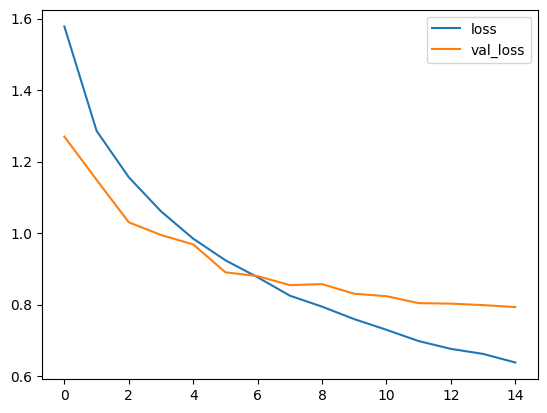

In [7]:
# taxas de erro por iteração
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

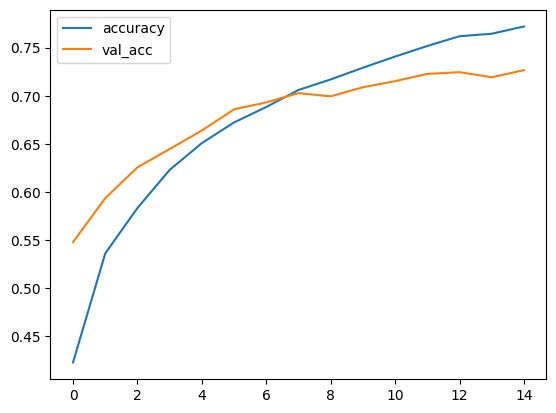

In [8]:
# taxas de erro e acurácia
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

 17/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  

2026-02-26 15:46:31.188410: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 122880000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Confusion matrix, without normalization
[[728   8  42  17  19   2   9  10 118  47]
 [ 26 809   0   7   4   2  10   1  37 104]
 [ 71   4 536  75 123  59  69  33  12  18]
 [ 22   9  47 530  77 161  56  51  23  24]
 [ 23   2  42  53 707  28  46  80  15   4]
 [ 10   5  35 179  58 601  36  55   8  13]
 [  2   4  21  65  56  15 820   5   5   7]
 [ 16   0  11  32  61  34  10 814   4  18]
 [ 37  26   6  13   5   3  10   4 868  28]
 [ 22  58   2  11   4   3   4  19  24 853]]


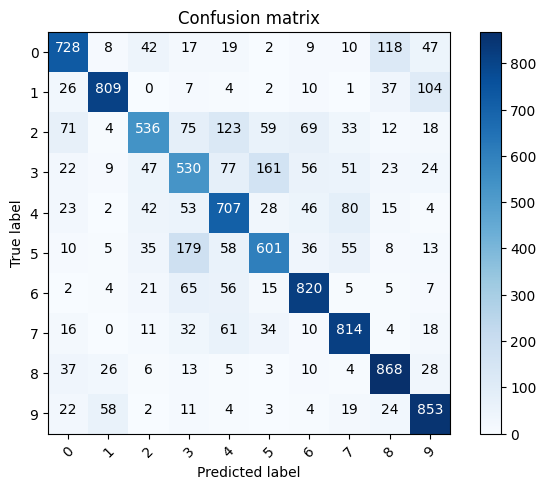

In [9]:
# Matriz de confusão
from sklearn.metrics import confusion_matrix
import itertools

def plot_confusion_matrix(cm,
                          classes, # Classes
                          normalize=False, # Normalização
                          title='Confusion matrix', 
                          cmap=plt.cm.Blues # Cor
                          ):
    # normalização da matriz 
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print("Confusion matrix, without normalization")
    print(cm)
    
    # plotagem da matriz 
    plt.imshow(cm, interpolation='nearest', cmap=cmap) # imagem da matriz 
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes)) # Marcas
    plt.xticks(tick_marks, classes, rotation=45) # rotulos do eixo x 
    plt.yticks(tick_marks, classes) # rotulos do eixo y
    
    # formatação dos números
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2. # limiar para a cor do texto
    # adicionando texto na matriz
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                horizontalalignment='center',
                color='white' if cm[i, j] > thresh else 'black')
    
    # adicionando rotulos
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# fazendo a predição
p_test = model.predict(x_test).argmax(axis=1)
# gerando a matriz de confusão
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, list(range(10)))